## our analysis

| 套件名稱 (Library) | 核心角色 (Core Role) | 實務具體用途 (Specific Use Case) |
| :--- | :--- | :--- |
| **Pandas** | [cite_start]資料表操作（DataFrame-based manipulation） [cite: 151, 172] | [cite_start]用於對資料陣列進行轉換、清洗與特徵調整。 [cite: 151] |
| **NumPy** | [cite_start]高效率數值與矩陣運算（Numerical arrays） [cite: 152, 175] | [cite_start]用於進行高效的數值計算與線性代數矩陣運算。 [cite: 152, 175] |
| **SciPy** | [cite_start]科學計算與進階統計（Scientific computing） [cite: 155, 183] | [cite_start]包含最佳化、插值、特徵值以及雙樣本 T 檢定等統計演算法。 [cite: 155] |
| **Matplotlib** | [cite_start]基礎數學與數據視覺化（Core plotting） [cite: 153, 178] | [cite_start]提供底層繪圖控制，用來微調圖表標題、軸線與顯示格式。 [cite: 153] |
| **Seaborn** | [cite_start]統計數據視覺化（Statistical visualization） [cite: 154, 181] | [cite_start]建立在 Matplotlib 之上，用於快速繪製美觀、高階的統計圖表。 [cite: 154, 181] |
| **scikit-learn** | [cite_start]預測性數據分析（Machine learning） [cite: 157, 185] | [cite_start]用於建立與評估機器學習模型（如迴歸、分類與資料集切分）。 [cite: 157, 185] |
| **shap** | [cite_start]模型決策可解釋性（Explainable ML） [cite: 158, 188] | [cite_start]利用 Shapley 值來拆解並解釋黑盒子模型中各特徵的影響力。 [cite: 158, 188] |

    budget_M  marketing_M  is_sequel  viewing_hours_M  total_spend_M
0  57.450712    19.404472          1       121.231948      76.855184
1  47.926035    18.536520          1       115.467455      66.462555
2  59.715328    22.229169          0       118.926651      81.944497
3  72.845448    25.249080          1       146.685702      98.094528
4  46.487699    18.623738          0        90.951494      65.111438
T 統計量: 3.0319
P 值: 3.1093e-03


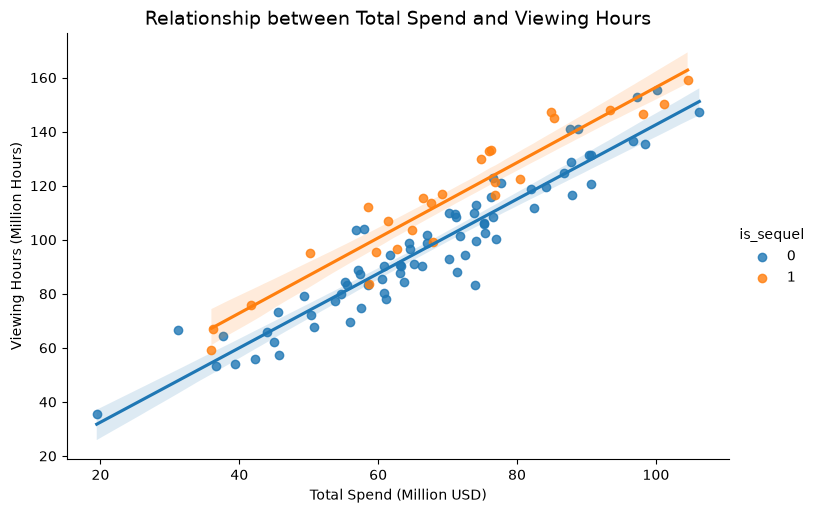

R² 判定係數: 0.7704
均方誤差 (MSE): 113.6193


/Users/vincent/Documents/netflix-writers/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/m3/mxn0108j41x3cp5x3trm41fh0000gn/T/ipykernel_39066/2429433558.py:82: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


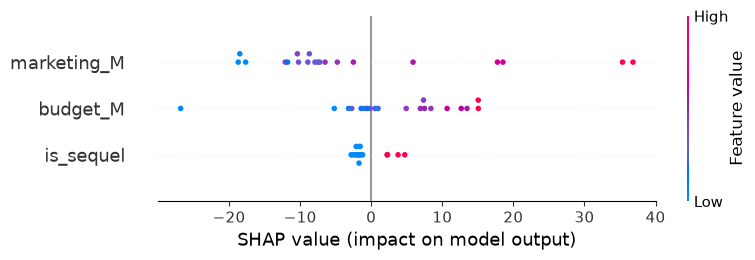

In [ ]:
import numpy as np
import pandas as pd

# NumPy: 用於高效率的數值運算與矩陣生成
np.random.seed(42)
n_samples = 100

# 模擬數據：預算（百萬美元）、行銷費用（百萬美元）、是否為續集（0或1）
budget = np.random.normal(50, 15, n_samples)          # 平均5000萬，標準差1500萬
marketing = budget * 0.3 + np.random.normal(5, 2, n_samples) # 行銷費用與預算正相關
is_sequel = np.random.binomial(1, 0.3, n_samples)     # 30%機率是續集

# 模擬目標值：觀看時數（百萬小時），加上一些隨機雜訊
viewing_hours = (budget * 1.2) + (marketing * 2.0) + (is_sequel * 15) + np.random.normal(0, 10, n_samples)

# Pandas: 將 NumPy 陣列轉換為結構化的 DataFrame，並進行資料操作
df = pd.DataFrame({
    'budget_M': budget,
    'marketing_M': marketing,
    'is_sequel': is_sequel,
    'viewing_hours_M': viewing_hours
})

# 簡單的特徵轉換 (Transformations)
df['total_spend_M'] = df['budget_M'] + df['marketing_M']
print(df.head())

from scipy import stats

# SciPy: 用於科學計算與統計檢定
sequel_hours = df[df['is_sequel'] == 1]['viewing_hours_M']
original_hours = df[df['is_sequel'] == 0]['viewing_hours_M']

# 執行雙獨立樣本 T 檢定 (T-test)
t_stat, p_value = stats.ttest_ind(sequel_hours, original_hours)

print(f"T 統計量: {t_stat:.4f}")
print(f"P 值: {p_value:.4e}")  # 若 P < 0.05，代表續集的觀看時數有顯著不同！

import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn: 建立統計圖表，觀察「總支出」與「觀看時數」的關係，並依據「是否為續集」著色
sns.lmplot(x='total_spend_M', y='viewing_hours_M', hue='is_sequel', data=df, aspect=1.5)

# Matplotlib: 用於調整圖表的細節設定（標題、標籤、儲存等）
plt.title("Relationship between Total Spend and Viewing Hours", fontsize=14)
plt.xlabel("Total Spend (Million USD)")
plt.ylabel("Viewing Hours (Million Hours)")

# 顯示圖表
plt.show()

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 準備特徵 (X) 與目標值 (y)
X = df[['budget_M', 'marketing_M', 'is_sequel']]
y = df['viewing_hours_M']

# 切分訓練集與測試集 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 初始化並訓練模型
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 進行預測與評估
y_pred = model.predict(X_test)
print(f"R² 判定係數: {r2_score(y_test, y_pred):.4f}")  # 越接近 1 代表預測越準
print(f"均方誤差 (MSE): {mean_squared_error(y_test, y_pred):.4f}")

import shap

# SHAP: 解釋隨機森林模型的預測行為
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# 繪製摘要圖 (Summary Plot)
# 這個圖會顯示哪些特徵影響最大（例如：行銷費用可能比預算更能拉高觀看時數）
shap.summary_plot(shap_values, X_test)

## our analysis
？？

## our analysis
？？

In [2]:
fruits = ["apple", "banana", "cherry"]

for fruit in fruits:
    print(f"I like {fruit}")

I like apple
I like banana
I like cherry


In [3]:
square = lambda x: x ** 2
print(square(5))   # 25

25
